# ROICaT PUAUC Training — Comprehensive Method Comparison
This notebook compares three ways to train a linear projection on ROInet embeddings using a **PUAUC** (Negative–Unlabeled AUC) objective on a sparse graph.

## Methods compared
1. **Baseline (Batch + Sparse Slicing + `masked_pairwise_similarity_dense`)** — closest to the original approach.
2. **Edge-CSR (Full Graph on Edges + row-loop loss)** — avoids sparse slicing; still loops over rows in Python.
3. **Vectorized GPU (Edge cosine + fixed K/M sampling + vectorized sqhinge)** — fastest; supports periodic resampling & eval.

At the end, there is a detailed markdown explanation of *what changes* between methods and *why* the vectorized GPU method is faster.

## 1) Environment setup (run first)
These thread limits help prevent OpenBLAS / MKL issues like `too many memory regions` on some systems.

In [1]:
import os

# Limit threads to reduce memory fragmentation / OpenBLAS issues
os.environ['OPENBLAS_NUM_THREADS'] = '32'
os.environ['MKL_NUM_THREADS'] = '32'
os.environ['OMP_NUM_THREADS'] = '32'
os.environ['NUMEXPR_NUM_THREADS'] = '32'

print("✓ Environment variables set")

✓ Environment variables set


## 2) Imports

In [2]:
import pickle
import time
from pathlib import Path

import numpy as np
import scipy.sparse
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

import roicat
import roicat.helpers

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


torch: 2.6.0
cuda available: False


## 3) Load preprocessed data
This notebook assumes you already saved preprocessed embeddings + sparse graphs into a single pickle.

In [3]:
# Path to your preprocessed pickle
save_path = '/workspace/syncthing/ROICaT_preprocessed/mouse_0322N_embeddings_and_graphs.pkl'

print("Loading:", save_path)
with open(save_path, 'rb') as f:
    data_loaded = pickle.load(f)

# Extract
rl = torch.as_tensor(data_loaded['rl'], dtype=torch.float32)  # (N, D) ROInet embeddings
adj = data_loaded['adj']                                     # scipy.sparse CSR
ssit = data_loaded['ssit']                                   # scipy.sparse CSR (same sparsity as adj)
sb = data_loaded.get('sb', None)                             # session_bool (optional)

print(f"N={rl.shape[0]:,}, D={rl.shape[1]}")
print(f"adj:  shape={adj.shape}, nnz={adj.nnz:,}")
print(f"ssit: shape={ssit.shape}, nnz={ssit.nnz:,}")


Loading: /workspace/syncthing/ROICaT_preprocessed/mouse_0322N_embeddings_and_graphs.pkl
N=16,955, D=128
adj:  shape=(16955, 16955), nnz=737,086
ssit: shape=(16955, 16955), nnz=737,086


## 4) Sanity checks on graph structure
For the fast methods, we rely on `adj` and `ssit` having **identical CSR structure**:
- same `indptr`
- same `indices`

If this is true, then `ssit.data` aligns one-to-one with `adj.data` for every edge.

In [4]:
def csr_same_structure(A: scipy.sparse.csr_matrix, B: scipy.sparse.csr_matrix) -> bool:
    return (A.shape == B.shape 
            and np.array_equal(A.indptr, B.indptr)
            and np.array_equal(A.indices, B.indices))

ok = csr_same_structure(adj, ssit)
print("ssit shares exact CSR structure with adj?", ok)
if not ok:
    raise RuntimeError("Expected ssit to share identical CSR structure with adj. Fast methods assume this.")

# Edge counts
same_edges = int(np.sum(ssit.data.astype(bool)))
cross_edges = int(ssit.nnz - same_edges)
print(f"edge_same_sesh: same={same_edges:,}  cross={cross_edges:,}")

# Rows with at least one same and one cross edge
deg = np.diff(adj.indptr)
deg_same = np.add.reduceat(ssit.data.astype(bool), adj.indptr[:-1])
deg_cross = deg - deg_same
valid_rows = np.where((deg_same > 0) & (deg_cross > 0))[0]
print(f"valid_rows: {len(valid_rows):,} / {adj.shape[0]:,}")


ssit shares exact CSR structure with adj? True
edge_same_sesh: same=137,524  cross=599,562
valid_rows: 16,884 / 16,955


## 5) Baseline method
This section reproduces the **batch + sparse slicing + `masked_pairwise_similarity_dense`** approach.

**Pros**: closest to the original; simplest conceptually.
**Cons**: slow due to repeated sparse slicing, conversions, and Python overhead; typically CPU-bound.

### 5.1 Minimal sparse containers + baseline PUAUC loss (row-loop)

In [5]:
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, Union, Literal

@dataclass
class SimpleCOO:
    row: torch.Tensor
    col: torch.Tensor
    val: torch.Tensor
    shape: Tuple[int, int]

    def sort_indices_(self):
        key = self.row * self.shape[1] + self.col
        perm = torch.argsort(key, stable=True)
        self.row = self.row[perm]
        self.col = self.col[perm]
        self.val = self.val[perm]

    def to_csr(self) -> "SimpleCSR":
        N, M = self.shape
        if self.row.numel() == 0:
            row_ptr = torch.zeros(N + 1, dtype=torch.int64, device=self.row.device)
            return SimpleCSR(
                row_ptr=row_ptr,
                col_idx=self.col.new_empty((0,), dtype=torch.int64),
                val=self.val.new_empty((0,)),
                shape=self.shape
            )

        row = self.row.to(torch.int64)
        col = self.col.to(torch.int64)
        val = self.val

        key = row * (M if M > 0 else 1) + col
        perm = torch.argsort(key, stable=True)
        row_s, col_s, val_s = row[perm], col[perm], val[perm]

        is_start = torch.ones_like(row_s, dtype=torch.bool)
        is_start[1:] = (row_s[1:] != row_s[:-1]) | (col_s[1:] != col_s[:-1])
        group_id = torch.cumsum(is_start.to(torch.int64), dim=0) - 1
        n_groups = int(group_id[-1].item()) + 1

        row_u = row_s[is_start]
        col_u = col_s[is_start]
        val_u = torch.zeros(n_groups, dtype=val_s.dtype, device=val_s.device)
        val_u.scatter_add_(0, group_id, val_s)

        counts = torch.bincount(row_u, minlength=N)
        row_ptr = torch.empty(N + 1, dtype=torch.int64, device=row.device)
        row_ptr[0] = 0
        row_ptr[1:] = torch.cumsum(counts, dim=0)

        return SimpleCSR(row_ptr=row_ptr, col_idx=col_u, val=val_u, shape=self.shape)

@dataclass
class SimpleCSR:
    row_ptr: torch.Tensor
    col_idx: torch.Tensor
    val: torch.Tensor
    shape: Tuple[int, int]

    @staticmethod
    def from_scipy(A) -> "SimpleCSR":
        import scipy.sparse as sp
        if sp.isspmatrix_coo(A):
            A = A.tocsr()
        return SimpleCSR(
            row_ptr=torch.tensor(A.indptr, dtype=torch.int64),
            col_idx=torch.tensor(A.indices, dtype=torch.int64),
            val=torch.tensor(A.data),
            shape=A.shape
        )

class PUAUCGraphLoss(torch.nn.Module):
    def __init__(
        self,
        *,
        surrogate: Literal["sqhinge", "logistic"] = "logistic",
        margin: float = 0.1,
        tau_pair: float = 0.05,
        max_pos_per_row: Optional[int] = 2,
        max_neg_per_row: Optional[int] = 256,
        eps: float = 1e-12,
    ) -> None:
        super().__init__()
        self.surrogate = surrogate
        self.margin = float(margin)
        self.tau_pair = float(tau_pair)
        self.max_pos_per_row = int(max_pos_per_row) if max_pos_per_row is not None else None
        self.max_neg_per_row = int(max_neg_per_row) if max_neg_per_row is not None else None
        self.eps = float(eps)

    def _row_slice(self, row_ptr, col_idx, vals, row: int):
        s, e = int(row_ptr[row].item()), int(row_ptr[row + 1].item())
        return col_idx[s:e], vals[s:e], s, e

    def forward(self, sim: SimpleCSR, s_sesh: SimpleCSR):
        if not (torch.equal(sim.row_ptr, s_sesh.row_ptr) and torch.equal(sim.col_idx, s_sesh.col_idx)):
            raise ValueError("sim and s_sesh must share identical CSR structure")

        row_ptr, col_idx, svals, ssv = sim.row_ptr, sim.col_idx, sim.val, s_sesh.val
        N, _ = sim.shape

        deg = row_ptr[1:] - row_ptr[:-1]
        row_e = torch.repeat_interleave(torch.arange(N, dtype=torch.int64), deg)

        same_mask = ssv.to(torch.bool)
        cross_mask = ~same_mask

        row_u = row_e[cross_mask]
        row_n = row_e[same_mask]

        has_u = torch.bincount(row_u, minlength=N) > 0
        has_n = torch.bincount(row_n, minlength=N) > 0
        valid_rows = torch.nonzero(has_u & has_n, as_tuple=False).flatten()

        losses = []
        rows_used = 0

        for i in valid_rows.tolist():
            _, sims_i, s, e = self._row_slice(row_ptr, col_idx, svals, i)
            ss_i = ssv[s:e].to(torch.bool)

            s_u_i = sims_i[~ss_i]
            s_n_i = sims_i[ss_i]

            if self.max_pos_per_row and s_u_i.numel() > self.max_pos_per_row:
                s_u_i = torch.topk(s_u_i, k=self.max_pos_per_row, largest=True, sorted=False)[0]
            if self.max_neg_per_row and s_n_i.numel() > self.max_neg_per_row:
                s_n_i = torch.topk(s_n_i, k=self.max_neg_per_row, largest=True, sorted=False)[0]

            if s_u_i.numel() == 0 or s_n_i.numel() == 0:
                continue

            rows_used += 1

            if self.surrogate == "sqhinge":
                s_n_sorted, _ = torch.sort(s_n_i)
                M = s_n_sorted.numel()

                ones = torch.ones_like(s_n_sorted)
                suff_cnt = torch.cumsum(ones.flip(0), dim=0).flip(0)
                suff_sum = torch.cumsum(s_n_sorted.flip(0), dim=0).flip(0)
                suff_s2  = torch.cumsum((s_n_sorted**2).flip(0), dim=0).flip(0)

                thresh = s_u_i - self.margin
                t = torch.searchsorted(s_n_sorted, thresh.clamp_min(-1e6))
                has_viols = t < M

                if has_viols.any():
                    t_idx = t[has_viols]
                    cnt = suff_cnt[t_idx]
                    sum_sn = suff_sum[t_idx]
                    sum_s2 = suff_s2[t_idx]
                    d = (self.margin - s_u_i[has_viols])
                    loss_i = ((d*d)*cnt + 2.0*d*sum_sn + sum_s2).sum()
                else:
                    loss_i = s_u_i.new_tensor(0.0)

                losses.append(loss_i / (s_u_i.numel() * M))
            else:
                su = s_u_i.unsqueeze(1)
                sn = s_n_i.unsqueeze(0)
                losses.append(F.softplus((sn - su) / max(self.tau_pair, 1e-6)).mean())

        if not losses:
            return svals.new_tensor(0.0, requires_grad=True), {"rows_used": 0}
        return torch.stack(losses).mean(), {"rows_used": rows_used}


### 5.2 Baseline training loop (batch slicing)
This is slow by design, but it’s valuable as a correctness/behavior reference.

**Tip:** run only a small number of iterations here once you trust the fast method.

In [6]:
# ---- Baseline config ----
# Baseline = batch slice -> masked_pairwise_similarity_dense -> convert -> Python row-loop logistic
# NOTE: this is meant as a "correctness reference" / bridge, not the fastest path.

baseline_device = "cpu"
print("baseline_device:", baseline_device)

puauc_baseline = PUAUCGraphLoss(
    surrogate="logistic",
    margin=0.1,
    tau_pair=0.05,
    max_pos_per_row=2,
    max_neg_per_row=256,
)

# Projection model (match your previous code: 128 -> 32 if n_layers=1)
rl2_cpu = rl.detach().cpu().float()
in_dim = rl2_cpu.shape[1]
out_dim = in_dim // 4  # 128 -> 32

proj_baseline = torch.nn.Linear(in_dim, out_dim, bias=False, device=baseline_device)
torch.nn.init.xavier_uniform_(proj_baseline.weight)
opt_baseline = torch.optim.Adam(proj_baseline.parameters(), lr=1e-2, weight_decay=1e-4)


# Add missing helper (needed if your earlier SimpleCOO definition didn't include it)
if not hasattr(SimpleCOO, "from_scipy"):
    @staticmethod
    def _from_scipy(A):
        import scipy.sparse as sp
        if sp.isspmatrix_csr(A):
            A = A.tocoo()
        elif sp.isspmatrix_coo(A):
            pass
        else:
            A = A.tocoo()
        return SimpleCOO(
            row=torch.tensor(A.row, dtype=torch.int64),
            col=torch.tensor(A.col, dtype=torch.int64),
            val=torch.tensor(A.data),
            shape=A.shape,
        )
    SimpleCOO.from_scipy = _from_scipy  # type: ignore[attr-defined]


def baseline_pipeline(
    emb: torch.Tensor,
    adj_batch: scipy.sparse.csr_matrix,
    ssit_batch: scipy.sparse.csr_matrix,
):
    """
    Returns: (loss, info)

    Key detail:
      - After slicing CSR matrices (adj[idx][:,idx]) SciPy can keep a valid CSR but with
        different internal *index ordering* conventions across matrices.
      - We force BOTH adj and ssit to the same canonical ordering before converting to torch.
      - We also build ssit via the same SimpleCOO->CSR codepath as sim to guarantee identical structure.
    """
    # 1) Canonicalize SciPy CSR order (important after slicing)
    adj_batch = adj_batch.copy()
    ssit_batch = ssit_batch.copy()
    adj_batch.sort_indices()
    ssit_batch.sort_indices()

    # 2) Similarities on adjacency edges (returns edge list in canonical order)
    rlst = roicat.helpers.masked_pairwise_similarity_dense(
        X=emb,
        adjacency=adj_batch,
        metric="cosine",
        device="cpu",
        accum_dtype=torch.float32,
        return_tensor=False,
        indices_device="cpu",
        edges_per_chunk=102400,
        eps=1e-12,
    )

    # Build sim CSR (canonical)
    sim_coo = SimpleCOO(row=rlst[0], col=rlst[1], val=rlst[2], shape=rlst[3])
    sim_coo.sort_indices_()
    sim_csr = sim_coo.to_csr()
    sim_csr.val = sim_csr.val.float()

    # 3) Build ss CSR with the SAME canonicalization path
    ss_coo = SimpleCOO.from_scipy(ssit_batch)
    ss_coo.sort_indices_()
    ss_csr = ss_coo.to_csr()
    ss_csr.val = ss_csr.val.bool()

    # 4) Ensure structure tensors are identical dtype/device (torch.equal is strict)
    sim_csr.row_ptr = sim_csr.row_ptr.to("cpu", torch.int64)
    sim_csr.col_idx = sim_csr.col_idx.to("cpu", torch.int64)
    ss_csr.row_ptr  = ss_csr.row_ptr.to("cpu", torch.int64)
    ss_csr.col_idx  = ss_csr.col_idx.to("cpu", torch.int64)

    return puauc_baseline(sim_csr, ss_csr)


def benchmark_baseline(
    *,
    n_iters: int = 50,
    batch_size: int = 50000,
    warmup: int = 2,
    seed: int = 0,
    verbose_every: int = 5,
):
    """
    Returns dict with times/losses. We drop the first `warmup` iterations from timing stats.
    """
    rng = np.random.default_rng(seed)
    N = rl2_cpu.shape[0]
    batch_size = min(batch_size, N)

    iter_times = []
    losses = []
    rows_used = []

    for it in range(n_iters):
        t0 = time.time()
        idx = rng.choice(N, batch_size, replace=False)

        emb = proj_baseline(rl2_cpu)[idx]
        adj_b = adj[idx][:, idx]
        ssit_b = ssit[idx][:, idx]

        loss, info = baseline_pipeline(emb, adj_b, ssit_b)

        opt_baseline.zero_grad(set_to_none=True)
        loss.backward()
        opt_baseline.step()

        dt = time.time() - t0
        iter_times.append(dt)
        losses.append(float(loss.detach().cpu()))
        rows_used.append(int(info.get("rows_used", 0)))

        if (it % verbose_every) == 0 or it < 3:
            print(f"[baseline] it={it:03d} loss={losses[-1]:.6f} time={dt:.3f}s rows={rows_used[-1]}")

    times_used = np.array(iter_times[warmup:], dtype=float) if n_iters > warmup else np.array(iter_times, dtype=float)

    out = {
        "method": "Baseline (batch slice + masked_pairwise_similarity_dense)",
        "device": "cpu",
        "n_iters": n_iters,
        "batch_size": batch_size,
        "warmup": warmup,
        "times": iter_times,
        "losses": losses,
        "rows_used": rows_used,
        "avg_sec_per_iter": float(times_used.mean()) if len(times_used) else float("nan"),
        "std_sec_per_iter": float(times_used.std(ddof=1)) if len(times_used) > 1 else float("nan"),
        "p50_sec_per_iter": float(np.median(times_used)) if len(times_used) else float("nan"),
        "p90_sec_per_iter": float(np.quantile(times_used, 0.9)) if len(times_used) else float("nan"),
    }
    return out


# ---- Run baseline benchmark (toggle) ----
run_baseline_demo = True  # set True to measure baseline timing
baseline_results = None

if run_baseline_demo:
    baseline_results = benchmark_baseline(n_iters=20, batch_size=50000, warmup=2, seed=0, verbose_every=5)
    print("\nBaseline avg time:", baseline_results["avg_sec_per_iter"], "sec/iter (post-warmup)")


baseline_device: cpu
[baseline] it=000 loss=0.052894 time=6.385s rows=16884
[baseline] it=001 loss=0.044768 time=6.748s rows=16884
[baseline] it=002 loss=0.039380 time=6.664s rows=16884
[baseline] it=005 loss=0.030046 time=6.678s rows=16884
[baseline] it=010 loss=0.022406 time=6.873s rows=16884
[baseline] it=015 loss=0.018198 time=6.813s rows=16884

Baseline avg time: 6.747132698694865 sec/iter (post-warmup)


## 6) Fast methods: work directly on edges
We extract a canonical edge list `(edge_row, edge_col)` from `adj`'s CSR indices.

Because `ssit` shares the same CSR structure, `edge_same_sesh = ssit.data.astype(bool)` aligns edge-by-edge.

This eliminates:
- batch sparse slicing `adj[idx][:,idx]`
- dense similarity building
- COO→CSR conversions each iteration

In [7]:
# Canonical edge list from CSR
N = adj.shape[0]
edge_row = np.repeat(np.arange(N, dtype=np.int64), np.diff(adj.indptr))
edge_col = adj.indices.astype(np.int64, copy=False)
edge_same_sesh = ssit.data.astype(bool, copy=False)

print(f"adj: N={N:,}  E={adj.nnz:,}")
print("edge_row:", edge_row.shape, "edge_col:", edge_col.shape)
print(f"edge_same_sesh: same={edge_same_sesh.sum():,} cross={(~edge_same_sesh).sum():,}")

# Optional quick alignment sanity check
rng = np.random.default_rng(0)
check = 200
ix = rng.integers(0, adj.nnz, size=check)
mismatch = int(np.sum(edge_same_sesh[ix] != ssit.data[ix].astype(bool)))
print("Random edge label mismatches:", mismatch, "out of", check)
if mismatch != 0:
    raise RuntimeError("ssit.data not aligned to adj edge ordering")


adj: N=16,955  E=737,086
edge_row: (737086,) edge_col: (737086,)
edge_same_sesh: same=137,524 cross=599,562
Random edge label mismatches: 0 out of 200


## 7) Method 2: Edge-CSR + row-loop loss (semi-optimized)
This avoids slicing and rebuilding sparse matrices, but still loops over rows in Python.

Good as an intermediate step / correctness bridge, but not the fastest.

In [8]:
# Semi-optimized: cosine on fixed edges + CSR reuse + Python row-loop sqhinge loss.

# Canonical edge list from CSR (adj / ssit share identical CSR structure on the FULL graph)
N = adj.shape[0]
edge_row = np.repeat(np.arange(N, dtype=np.int64), np.diff(adj.indptr))
edge_col = adj.indices.astype(np.int64, copy=False)
edge_same_sesh = ssit.data.astype(bool, copy=False)

print(f"adj: N={N:,}  E={adj.nnz:,}")
print("edge_row:", edge_row.shape, "edge_col:", edge_col.shape)
print(f"edge_same_sesh: same={edge_same_sesh.sum():,} cross={(~edge_same_sesh).sum():,}")

# Precompute row_ptr once from CSR
row_ptr = torch.as_tensor(adj.indptr, dtype=torch.int64, device="cpu")
edge_row_t_cpu = torch.as_tensor(edge_row, dtype=torch.int64, device="cpu")
edge_col_t_cpu = torch.as_tensor(edge_col, dtype=torch.int64, device="cpu")
same_t_cpu = torch.as_tensor(edge_same_sesh, dtype=torch.bool, device="cpu")

puauc_sqhinge_rowloop = PUAUCGraphLoss(
    surrogate="sqhinge",
    margin=0.1,
    max_pos_per_row=2,
    max_neg_per_row=32,
)

def sim_on_edges_cpu(emb_cpu: torch.Tensor) -> torch.Tensor:
    zi = F.normalize(emb_cpu[edge_row_t_cpu], dim=1, eps=1e-12)
    zj = F.normalize(emb_cpu[edge_col_t_cpu], dim=1, eps=1e-12)
    return (zi * zj).sum(dim=1)  # (E,)

def loss_edgecsr_rowloop(emb_cpu: torch.Tensor):
    sim_vals = sim_on_edges_cpu(emb_cpu).float()
    sim_csr = SimpleCSR(row_ptr=row_ptr, col_idx=edge_col_t_cpu, val=sim_vals, shape=(N, N))
    ss_csr  = SimpleCSR(row_ptr=row_ptr, col_idx=edge_col_t_cpu, val=same_t_cpu, shape=(N, N))
    loss, info = puauc_sqhinge_rowloop(sim_csr, ss_csr)
    return loss, info


def benchmark_semi(
    *,
    n_iters: int = 50,
    warmup: int = 2,
    seed: int = 0,
    verbose_every: int = 5,
):
    """
    Semi-opt benchmark:
      - No slicing
      - Similarity computed on E fixed edges
      - Loss still loops over rows in Python

    We drop the first `warmup` iterations from timing stats.
    """
    torch.manual_seed(seed)
    rl_cpu = rl.detach().cpu().float()

    proj = torch.nn.Linear(rl_cpu.shape[1], rl_cpu.shape[1] // 4, bias=False)
    torch.nn.init.xavier_uniform_(proj.weight)
    opt = torch.optim.Adam(proj.parameters(), lr=1e-2, weight_decay=1e-4)

    iter_times = []
    losses = []
    rows_used = []

    for it in range(n_iters):
        t0 = time.time()
        emb = proj(rl_cpu)
        loss, info = loss_edgecsr_rowloop(emb)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        dt = time.time() - t0
        iter_times.append(dt)
        losses.append(float(loss.detach().cpu()))
        rows_used.append(int(info.get("rows_used", 0)))

        if (it % verbose_every) == 0 or it < 3:
            print(f"[semi] it={it:03d} loss={losses[-1]:.6f} time={dt:.3f}s rows={rows_used[-1]}")

    times_used = np.array(iter_times[warmup:], dtype=float) if n_iters > warmup else np.array(iter_times, dtype=float)

    out = {
        "method": "Edge-CSR row-loop sqhinge",
        "device": "cpu",
        "n_iters": n_iters,
        "warmup": warmup,
        "times": iter_times,
        "losses": losses,
        "rows_used": rows_used,
        "avg_sec_per_iter": float(times_used.mean()) if len(times_used) else float("nan"),
        "std_sec_per_iter": float(times_used.std(ddof=1)) if len(times_used) > 1 else float("nan"),
        "p50_sec_per_iter": float(np.median(times_used)) if len(times_used) else float("nan"),
        "p90_sec_per_iter": float(np.quantile(times_used, 0.9)) if len(times_used) else float("nan"),
    }
    return out


# ---- Run semi benchmark (toggle) ----
run_semi_demo = True  # set True to measure semi timing
semi_results = None

if run_semi_demo:
    semi_results = benchmark_semi(n_iters=20, warmup=2, seed=0, verbose_every=5)
    print("\nSemi avg time:", semi_results["avg_sec_per_iter"], "sec/iter (post-warmup)")


adj: N=16,955  E=737,086
edge_row: (737086,) edge_col: (737086,)
edge_same_sesh: same=137,524 cross=599,562
[semi] it=000 loss=0.000769 time=6.955s rows=16884
[semi] it=001 loss=0.000652 time=7.691s rows=16884
[semi] it=002 loss=0.000572 time=7.613s rows=16884
[semi] it=005 loss=0.000457 time=8.079s rows=16884
[semi] it=010 loss=0.000350 time=7.635s rows=16884
[semi] it=015 loss=0.000249 time=7.200s rows=16884

Semi avg time: 7.69515770011478 sec/iter (post-warmup)


## 8) Method 3 (recommended): Vectorized GPU training
Core idea:
- compute cosine similarities **only on edges**
- pre-sample a fixed number of cross edges (**K**) and same-session edges (**M**) per row
- compute sqhinge loss **fully vectorized** on GPU (no Python row loops)

This is what gave you ~0.004s/iter.

### Key controls
- `K` (cross edges per row): usually 1–4
- `M` (same edges per row): usually 4–32
- `R` (rows sampled per iter): tradeoff coverage vs speed
- `resample_every`: resample indices periodically to avoid plateaus
- `eval_every`: evaluate on a held-out index set

In [9]:
# Build valid_rows again as numpy array (already computed earlier)
# valid_rows: np.ndarray

def sample_fixed_KM_indices(
    indptr: np.ndarray,
    same_mask: np.ndarray,
    valid_rows: np.ndarray,
    *,
    R: int,
    K: int,
    M: int,
    seed: int = 0,
):
    rng = np.random.default_rng(seed)

    deg = np.diff(indptr)
    deg_same = np.add.reduceat(same_mask, indptr[:-1])
    deg_cross = deg - deg_same

    eligible = valid_rows[(deg_cross[valid_rows] >= K) & (deg_same[valid_rows] >= M)]
    if len(eligible) == 0:
        raise RuntimeError(f"No eligible rows with K={K}, M={M}. Try smaller M.")

    rows_sel = eligible if R > len(eligible) else rng.choice(eligible, size=R, replace=False)

    U_idx = np.empty((len(rows_sel), K), dtype=np.int64)
    N_idx = np.empty((len(rows_sel), M), dtype=np.int64)

    for t, r in enumerate(rows_sel):
        s, e = indptr[r], indptr[r+1]
        edges = np.arange(s, e, dtype=np.int64)
        sm = same_mask[s:e]
        same_edges = edges[sm]
        cross_edges = edges[~sm]
        U_idx[t] = rng.choice(cross_edges, size=K, replace=False)
        N_idx[t] = rng.choice(same_edges, size=M, replace=False)

    return rows_sel, U_idx, N_idx

def sim_on_edges(emb: torch.Tensor, edge_row_t: torch.Tensor, edge_col_t: torch.Tensor) -> torch.Tensor:
    zi = F.normalize(emb[edge_row_t], dim=1, eps=1e-12)
    zj = F.normalize(emb[edge_col_t], dim=1, eps=1e-12)
    return (zi * zj).sum(dim=1)  # (E,)

def puauc_sqhinge_vectorized(sim_vals: torch.Tensor, U_idx: torch.Tensor, N_idx: torch.Tensor, margin: float) -> torch.Tensor:
    s_u = sim_vals[U_idx]  # (R, K)
    s_n = sim_vals[N_idx]  # (R, M)
    d = margin + s_n.unsqueeze(1) - s_u.unsqueeze(2)  # (R, K, M)
    z = torch.clamp(d, min=0.0)
    return (z * z).mean()

print("✓ vectorized components ready")


✓ vectorized components ready


### 8.1 Recommended training harness (resampling + held-out eval)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

margin = 0.1
K = 2          # cross edges per row
M = 8          # same edges per row
R_train = 8000 # rows per iteration (tune)
R_eval  = 2000

resample_every = 25
eval_every = 10
seed0 = 123

rl2 = rl.detach().to(device).float()
proj = torch.nn.Linear(rl2.shape[1], rl2.shape[1]//4, bias=False, device=device)
torch.nn.init.xavier_uniform_(proj.weight)
optim = torch.optim.Adam(proj.parameters(), lr=1e-2, weight_decay=1e-4)

edge_row_t = torch.as_tensor(edge_row, dtype=torch.int64, device=device)
edge_col_t = torch.as_tensor(edge_col, dtype=torch.int64, device=device)

rows_eval, U_eval, N_eval = sample_fixed_KM_indices(
    indptr=adj.indptr,
    same_mask=edge_same_sesh,
    valid_rows=valid_rows,
    R=R_eval, K=K, M=M, seed=seed0 + 999,
)

def make_train_indices(seed: int):
    return sample_fixed_KM_indices(
        indptr=adj.indptr,
        same_mask=edge_same_sesh,
        valid_rows=valid_rows,
        R=R_train, K=K, M=M, seed=seed,
    )

rows_train, U_train, N_train = make_train_indices(seed0)

U_train_t = torch.as_tensor(U_train, dtype=torch.int64, device=device)
N_train_t = torch.as_tensor(N_train, dtype=torch.int64, device=device)
U_eval_t  = torch.as_tensor(U_eval,  dtype=torch.int64, device=device)
N_eval_t  = torch.as_tensor(N_eval,  dtype=torch.int64, device=device)

print(f"Train rows={len(rows_train):,}  Eval rows={len(rows_eval):,}  K={K}  M={M}")
print("U_train_t:", tuple(U_train_t.shape), "N_train_t:", tuple(N_train_t.shape))


device: cuda
Train rows=7,380  Eval rows=2,000  K=2  M=8
U_train_t: (7380, 2) N_train_t: (7380, 8)


In [11]:
def eval_loss(proj, rl2, edge_row_t, edge_col_t, U_eval_t, N_eval_t, margin: float):
    with torch.no_grad():
        emb = proj(rl2)
        sim_vals = sim_on_edges(emb, edge_row_t, edge_col_t)
        return float(puauc_sqhinge_vectorized(sim_vals, U_eval_t, N_eval_t, margin).detach().cpu())

n_iters = 100
train_losses = []
eval_losses = []
iter_times = []

t_all = time.time()
for it in range(n_iters):
    it0 = time.time()

    if (it % resample_every) == 0 and it != 0:
        rows_train, U_train, N_train = make_train_indices(seed0 + it)
        U_train_t = torch.as_tensor(U_train, dtype=torch.int64, device=device)
        N_train_t = torch.as_tensor(N_train, dtype=torch.int64, device=device)

    emb = proj(rl2)
    sim_vals = sim_on_edges(emb, edge_row_t, edge_col_t)
    loss = puauc_sqhinge_vectorized(sim_vals, U_train_t, N_train_t, margin=margin)

    optim.zero_grad(set_to_none=True)
    loss.backward()
    optim.step()

    dt = time.time() - it0
    iter_times.append(dt)
    train_losses.append(float(loss.detach().cpu()))

    if (it % eval_every) == 0 or it < 3:
        el = eval_loss(proj, rl2, edge_row_t, edge_col_t, U_eval_t, N_eval_t, margin)
        eval_losses.append((it, el))
        print(f"iter {it:03d} | train={train_losses[-1]:.6f} | eval={el:.6f} | time={dt:.4f}s")

print(f"Done in {time.time()-t_all:.2f}s  avg={np.mean(iter_times):.5f}s/iter")


iter 000 | train=0.082211 | eval=0.059370 | time=0.3569s
iter 001 | train=0.058785 | eval=0.047236 | time=0.0029s
iter 002 | train=0.047033 | eval=0.038901 | time=0.0022s
iter 010 | train=0.014922 | eval=0.014705 | time=0.0030s
iter 020 | train=0.010600 | eval=0.010949 | time=0.0035s
iter 030 | train=0.010322 | eval=0.010344 | time=0.0030s
iter 040 | train=0.010093 | eval=0.010156 | time=0.0031s
iter 050 | train=0.010060 | eval=0.010086 | time=0.1935s
iter 060 | train=0.009994 | eval=0.010050 | time=0.0031s
iter 070 | train=0.009925 | eval=0.010032 | time=0.0030s
iter 080 | train=0.010007 | eval=0.010021 | time=0.0031s
iter 090 | train=0.009935 | eval=0.010004 | time=0.0031s
Done in 1.83s  avg=0.01236s/iter


In [ ]:
import numpy as np
import scipy.sparse
import torch
import torch.nn.functional as F

class VectorizedPUAUCLoss(torch.nn.Module):
    """
    Method 3: Vectorized GPU Loss for PUAUC (Positive-Unlabeled AUC).
    
    This method assumes:
      1. 'Same-session' edges (ssit) are hard negatives (cannot be the same neuron).
      2. 'Cross-session' edges (adj & ~ssit) are unlabeled candidates (potential positives).
      
    It optimizes the objective: Sim(Cross) > Sim(Same) + Margin.
    """
    
    def __init__(
        self,
        adj: scipy.sparse.csr_matrix,
        ssit: scipy.sparse.csr_matrix,
        device: torch.device,
        margin: float = 0.1,
        K: int = 2,          # Number of cross-session (unlabeled) edges to sample per row
        M: int = 8,          # Number of same-session (negative) edges to sample per row
        R_sample: int = 8000, # Number of rows to sample per resampling step
        resample_every: int = 25,
        seed: int = 0
    ):
        super().__init__()
        self.margin = margin
        self.K = K
        self.M = M
        self.R_sample = R_sample
        self.resample_every = resample_every
        self.device = device
        self.seed = seed
        self.step_counter = 0
        
        # --- 1. Graph Preprocessing (CPU) ---
        # Ensure identical structure
        if not (adj.indptr.shape == ssit.indptr.shape and 
                np.array_equal(adj.indptr, ssit.indptr) and 
                np.array_equal(adj.indices, ssit.indices)):
            raise ValueError("adj and ssit must share identical CSR structure (indptr/indices).")

        self.N = adj.shape[0]
        self.indptr = adj.indptr
        
        # Create canonical edge lists
        # edge_row: source node index for every edge
        self.edge_row_cpu = np.repeat(np.arange(self.N, dtype=np.int64), np.diff(self.indptr))
        self.edge_col_cpu = adj.indices.astype(np.int64)
        
        # Boolean mask: True if edge is same-session, False if cross-session
        self.same_mask_cpu = ssit.data.astype(bool)
        
        # --- 2. Filter Valid Rows ---
        # We need rows that have at least K cross edges and M same edges
        deg = np.diff(self.indptr)
        deg_same = np.add.reduceat(self.same_mask_cpu, self.indptr[:-1])
        deg_cross = deg - deg_same
        
        self.valid_rows = np.where((deg_cross >= K) & (deg_same >= M))[0]
        if len(self.valid_rows) == 0:
            raise RuntimeError(f"No valid rows found with K={K} (cross) and M={M} (same). Try reducing M.")
            
        print(f"VectorizedPUAUCLoss initialized: {len(self.valid_rows)}/{self.N} valid rows. "
              f"Sampling {R_sample} rows every {resample_every} steps.")

        # --- 3. Move Static Graph Data to GPU ---
        # We compute cosine similarity for ALL edges on the GPU, so we need these tensors resident.
        self.edge_row_t = torch.as_tensor(self.edge_row_cpu, dtype=torch.int64, device=device)
        self.edge_col_t = torch.as_tensor(self.edge_col_cpu, dtype=torch.int64, device=device)
        
        # Placeholders for active indices (will be set by resample)
        self.U_idx_t = None # Indices into edge list for Unlabeled (cross) edges
        self.N_idx_t = None # Indices into edge list for Negative (same) edges
        
        # Initial sampling
        self.resample()

    def resample(self):
        """
        Samples a fixed set of R rows, and for each row samples K cross edges and M same edges.
        This runs on CPU using numpy for efficiency, then transfers indices to GPU.
        """
        rng = np.random.default_rng(self.seed + self.step_counter)
        
        # Select rows
        if self.R_sample >= len(self.valid_rows):
            rows_sel = self.valid_rows
        else:
            rows_sel = rng.choice(self.valid_rows, size=self.R_sample, replace=False)
            
        # Containers for edge indices
        # We want to store the INDEX into the edge array (0..E-1), not the column node ID
        U_idx = np.empty((len(rows_sel), self.K), dtype=np.int64)
        N_idx = np.empty((len(rows_sel), self.M), dtype=np.int64)
        
        # Loop over sampled rows to pick specific edges
        # Note: This Python loop is acceptable because R_sample is relatively small (e.g. 8000)
        # and it only runs once every 'resample_every' iterations.
        for t, r in enumerate(rows_sel):
            s, e = self.indptr[r], self.indptr[r+1]
            
            # These are indices into the edge list (0..E)
            edges_range = np.arange(s, e, dtype=np.int64)
            sm = self.same_mask_cpu[s:e]
            
            same_edges = edges_range[sm]
            cross_edges = edges_range[~sm]
            
            # Random choice
            U_idx[t] = rng.choice(cross_edges, size=self.K, replace=False)
            N_idx[t] = rng.choice(same_edges, size=self.M, replace=False)
            
        # Transfer to GPU
        self.U_idx_t = torch.as_tensor(U_idx, dtype=torch.int64, device=self.device)
        self.N_idx_t = torch.as_tensor(N_idx, dtype=torch.int64, device=self.device)

    def forward(self, embeddings: torch.Tensor) -> torch.Tensor:
        """
        Args:
            embeddings: (N, D) tensor of ALL node embeddings.
        Returns:
            Scalar loss.
        """
        # 1. Periodic Resampling
        if self.step_counter > 0 and (self.step_counter % self.resample_every) == 0:
            self.resample()
        self.step_counter += 1
        
        # 2. Compute similarity on ALL edges (Vectorized GPU operation)
        #    This is fast: O(E * D)
        #    zi = embeddings[row], zj = embeddings[col]
        #    sim = (zi * zj).sum(1)
        #    Using F.normalize ensures cosine similarity.
        emb_norm = F.normalize(embeddings, dim=1, eps=1e-12)
        zi = emb_norm[self.edge_row_t]
        zj = emb_norm[self.edge_col_t]
        sim_vals = (zi * zj).sum(dim=1) # Shape: (num_edges,)
        
        # 3. Gather pre-sampled similarities
        #    U_idx_t shape: (R, K) -> s_u shape: (R, K)
        #    N_idx_t shape: (R, M) -> s_n shape: (R, M)
        s_u = sim_vals[self.U_idx_t] 
        s_n = sim_vals[self.N_idx_t]
        
        # 4. Vectorized Squared Hinge Loss
        #    Objective: s_u > s_n + margin
        #    Violation: d = (s_n + margin) - s_u
        #    We minimize sum(max(0, d)^2)
        
        # Broadcast subtraction: (R, 1, M) - (R, K, 1) -> (R, K, M)
        d = self.margin + s_n.unsqueeze(1) - s_u.unsqueeze(2)
        z = torch.clamp(d, min=0.0)
        loss = (z * z).mean()
        
        return loss

### 8.2 Plot training + eval curves

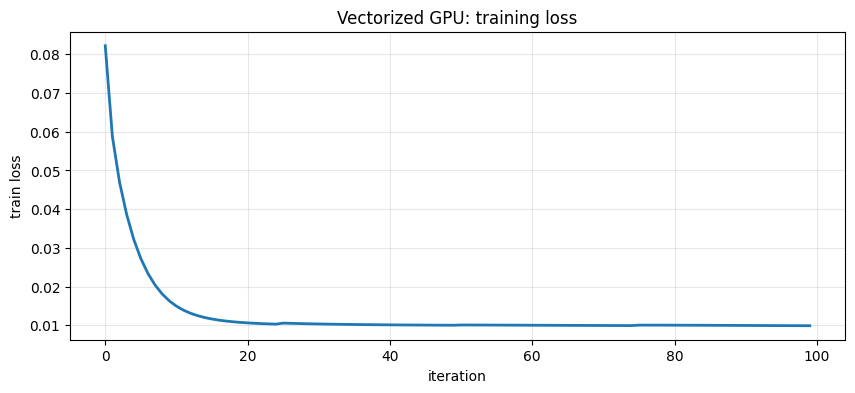

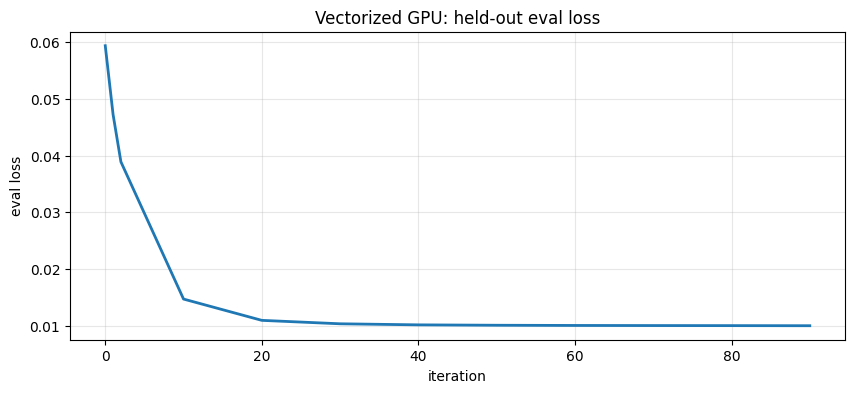

In [12]:
plt.figure(figsize=(10,4))
plt.plot(train_losses, linewidth=2)
plt.xlabel("iteration")
plt.ylabel("train loss")
plt.title("Vectorized GPU: training loss")
plt.grid(True, alpha=0.3)
plt.show()

if len(eval_losses) > 0:
    its = [x[0] for x in eval_losses]
    els = [x[1] for x in eval_losses]
    plt.figure(figsize=(10,4))
    plt.plot(its, els, linewidth=2)
    plt.xlabel("iteration")
    plt.ylabel("eval loss")
    plt.title("Vectorized GPU: held-out eval loss")
    plt.grid(True, alpha=0.3)
    plt.show()


## 9) Correctness check: vectorized vs brute (small subset)

In [13]:
def puauc_sqhinge_bruteforce(sim_vals: torch.Tensor, U_idx: torch.Tensor, N_idx: torch.Tensor, margin: float) -> torch.Tensor:
    s_u = sim_vals[U_idx]
    s_n = sim_vals[N_idx]
    d = margin + s_n.unsqueeze(1) - s_u.unsqueeze(2)
    z = torch.clamp(d, min=0.0)
    return (z*z).mean()

rows_chk, U_chk, N_chk = sample_fixed_KM_indices(
    indptr=adj.indptr,
    same_mask=edge_same_sesh,
    valid_rows=valid_rows,
    R=200, K=min(K,2), M=min(M,8),
    seed=9999,
)
U_chk_t = torch.as_tensor(U_chk, dtype=torch.int64, device=device)
N_chk_t = torch.as_tensor(N_chk, dtype=torch.int64, device=device)

with torch.no_grad():
    emb = proj(rl2)
    sim_vals = sim_on_edges(emb, edge_row_t, edge_col_t)

ref = puauc_sqhinge_bruteforce(sim_vals, U_chk_t, N_chk_t, margin=margin)
fast = puauc_sqhinge_vectorized(sim_vals, U_chk_t, N_chk_t, margin=margin)
print("Reference (brute):", float(ref.detach().cpu()))
print("Vectorized fast  :", float(fast.detach().cpu()))
print("Abs diff         :", float((ref-fast).abs().detach().cpu()))


Reference (brute): 0.01007877942174673
Vectorized fast  : 0.01007877942174673
Abs diff         : 0.0


## 10) Summary benchmark table

In [14]:
# Summary benchmark table (fills in numbers if you ran the benchmarks above)

def _safe_get(d, k, default=np.nan):
    return default if d is None else d.get(k, default)

# Vectorized timing should exist as `iter_times` from the vectorized training cell.
vec_avg = np.mean(iter_times) if "iter_times" in globals() and len(iter_times) else np.nan
vec_std = np.std(iter_times, ddof=1) if "iter_times" in globals() and len(iter_times) > 1 else np.nan
vec_p50 = np.median(iter_times) if "iter_times" in globals() and len(iter_times) else np.nan
vec_p90 = np.quantile(iter_times, 0.9) if "iter_times" in globals() and len(iter_times) else np.nan

rows_train_ct = len(rows_train) if "rows_train" in globals() else np.nan

summary = [
    {
        "method": "Vectorized GPU (K/M sampling)",
        "device": device if "device" in globals() else "cuda",
        "avg_sec_per_iter": float(vec_avg),
        "std_sec_per_iter": float(vec_std),
        "p50_sec_per_iter": float(vec_p50),
        "p90_sec_per_iter": float(vec_p90),
        "notes": f"R_train={rows_train_ct}, K={K}, M={M}, resample_every={resample_every}"
                if "K" in globals() else "",
    },
    {
        "method": "Baseline (batch slice + masked_pairwise_similarity_dense)",
        "device": "cpu",
        "avg_sec_per_iter": float(_safe_get(baseline_results, "avg_sec_per_iter")),
        "std_sec_per_iter": float(_safe_get(baseline_results, "std_sec_per_iter")),
        "p50_sec_per_iter": float(_safe_get(baseline_results, "p50_sec_per_iter")),
        "p90_sec_per_iter": float(_safe_get(baseline_results, "p90_sec_per_iter")),
        "notes": "set run_baseline_demo=True (cell above) to measure",
    },
    {
        "method": "Edge-CSR row-loop sqhinge",
        "device": "cpu",
        "avg_sec_per_iter": float(_safe_get(semi_results, "avg_sec_per_iter")),
        "std_sec_per_iter": float(_safe_get(semi_results, "std_sec_per_iter")),
        "p50_sec_per_iter": float(_safe_get(semi_results, "p50_sec_per_iter")),
        "p90_sec_per_iter": float(_safe_get(semi_results, "p90_sec_per_iter")),
        "notes": "set run_semi_demo=True (cell above) to measure",
    },
]

summary_df = pd.DataFrame(summary)
summary_df

,method,device,avg_sec_per_iter,std_sec_per_iter,p50_sec_per_iter,p90_sec_per_iter,notes
0,Vectorized GPU (K/M sampling),cuda,0.012360,0.047953,0.003089,0.003441,"R_train=7380, K=2, M=8, resample_every=25"
1,Baseline (batch slice + masked_pairwise_simila...,cpu,6.747133,0.153910,6.788247,6.925785,set run_baseline_demo=True (cell above) to mea...
2,Edge-CSR row-loop sqhinge,cpu,7.695158,0.577485,7.775223,8.382219,set run_semi_demo=True (cell above) to measure


,method,iter,time_sec,loss
0,Vectorized GPU,0,0.356874,0.082211
1,Vectorized GPU,1,0.002944,0.058785
2,Vectorized GPU,2,0.002215,0.047033
3,Vectorized GPU,3,0.001880,0.038677
4,Vectorized GPU,4,0.001918,0.032191


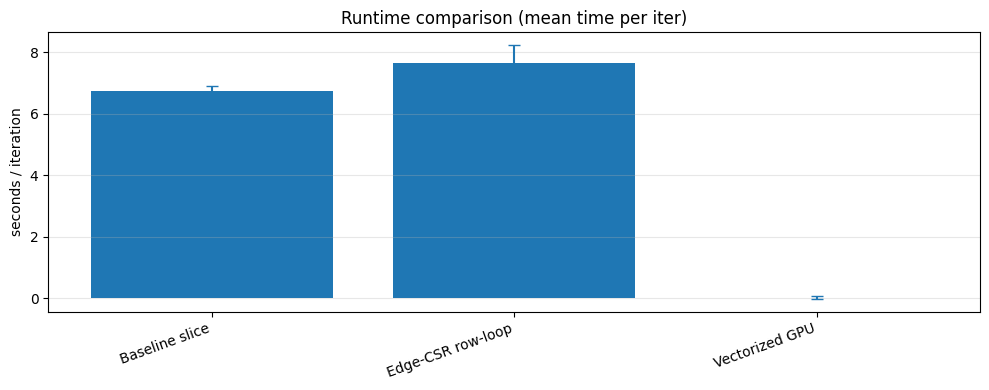

/tmp/ipykernel_3422729/1708305812.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=methods, showfliers=False)


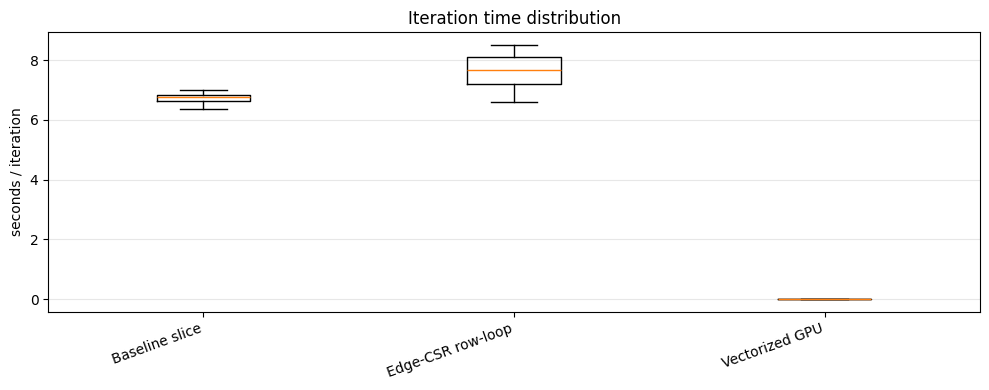

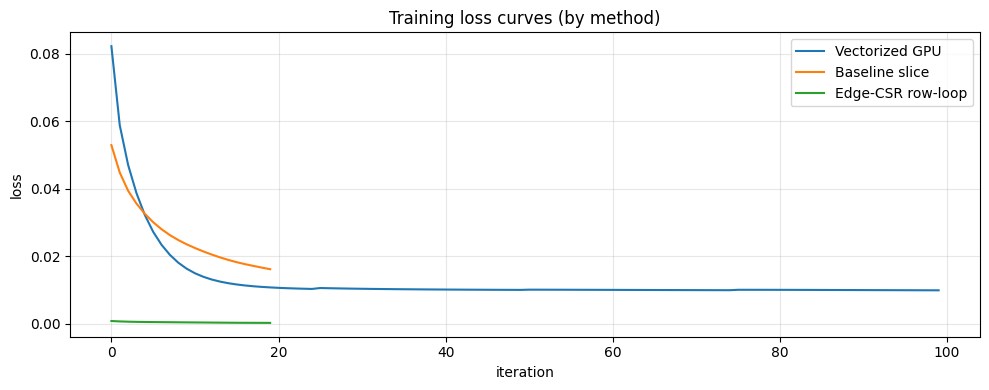

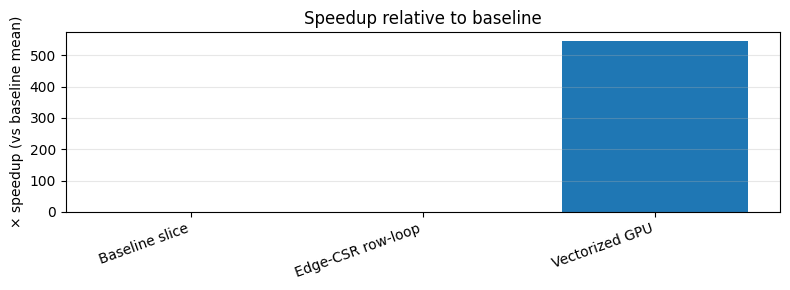

In [15]:
# Extra comparison stats + visuals (run after you have at least 2 methods measured)

def _make_long_df(label, times, losses):
    if times is None or len(times) == 0:
        return pd.DataFrame(columns=["method", "iter", "time_sec", "loss"])
    n = min(len(times), len(losses)) if losses is not None else len(times)
    df = pd.DataFrame({
        "method": label,
        "iter": np.arange(n),
        "time_sec": np.array(times[:n], dtype=float),
        "loss": np.array(losses[:n], dtype=float) if losses is not None else np.full(n, np.nan),
    })
    return df

frames = []

# Vectorized (already ran if you got iter_times/train_losses)
if "iter_times" in globals() and len(iter_times):
    frames.append(_make_long_df("Vectorized GPU", iter_times, train_losses if "train_losses" in globals() else None))

# Baseline
if baseline_results is not None:
    frames.append(_make_long_df("Baseline slice", baseline_results["times"], baseline_results["losses"]))

# Semi
if semi_results is not None:
    frames.append(_make_long_df("Edge-CSR row-loop", semi_results["times"], semi_results["losses"]))

long_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["method","iter","time_sec","loss"])
display(long_df.head())

# ---- Plots ----
if len(long_df):
    # 1) Bar chart: mean +- std time per iter
    plt.figure(figsize=(10, 4))
    grp = long_df.groupby("method")["time_sec"]
    means = grp.mean()
    stds = grp.std(ddof=1)

    x = np.arange(len(means))
    plt.bar(x, means.values)
    plt.xticks(x, means.index, rotation=20, ha="right")
    plt.ylabel("seconds / iteration")
    plt.title("Runtime comparison (mean time per iter)")
    # error bars (std)
    plt.errorbar(x, means.values, yerr=stds.values, fmt="none", capsize=4)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 2) Boxplot of iteration times (shows variability / warmup)
    plt.figure(figsize=(10, 4))
    methods = list(means.index)
    data = [long_df.loc[long_df["method"] == m, "time_sec"].values for m in methods]
    plt.boxplot(data, labels=methods, showfliers=False)
    plt.ylabel("seconds / iteration")
    plt.title("Iteration time distribution")
    plt.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    # 3) Loss curves (not strictly comparable if different objective/sampling, but useful)
    plt.figure(figsize=(10, 4))
    for m in long_df["method"].unique():
        sub = long_df[long_df["method"] == m].sort_values("iter")
        if sub["loss"].notna().any():
            plt.plot(sub["iter"].values, sub["loss"].values, label=m)
    plt.xlabel("iteration")
    plt.ylabel("loss")
    plt.title("Training loss curves (by method)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4) Speedup vs baseline (if available)
    if baseline_results is not None:
        base = baseline_results["avg_sec_per_iter"]
        plt.figure(figsize=(8, 3))
        speedups = []
        labels = []
        for m in means.index:
            speedups.append(base / means[m] if means[m] > 0 else np.nan)
            labels.append(m)
        plt.bar(np.arange(len(labels)), speedups)
        plt.xticks(np.arange(len(labels)), labels, rotation=20, ha="right")
        plt.ylabel("× speedup (vs baseline mean)")
        plt.title("Speedup relative to baseline")
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No timing data yet. Turn on run_baseline_demo / run_semi_demo and run the vectorized cell, then rerun this cell.")

## 11) Explanation: what differs between methods and why vectorized GPU is faster

### What all methods are trying to optimize
We have:
- node embeddings $z_i \in \mathbb{R}^d$ (ROInet features after a learnable projection)
- a sparse graph of candidate pairs (edges from `adj`)
- a binary indicator per edge from `ssit`:
  - **same-session edges** = labeled *negatives*
  - **cross-session edges** = *unlabeled*

For each anchor node $i$, we want cross-session similarities to rank **above** same-session similarities:
$$ s(i, u) \;\text{should be} \;>\; s(i, n) \quad \text{for } u \in U(i),\; n \in N(i) $$
where $s(\cdot,\cdot)$ is cosine similarity.

A squared-hinge surrogate is:
$$ \ell_i = \frac{1}{|U(i)||N(i)|} \sum_{u\in U(i)} \sum_{n\in N(i)} \max(0,\; m + s(i,n) - s(i,u))^2 $$
and the total loss is the mean over eligible rows.

---
### Baseline (batch slicing)
**Per iteration**: batch nodes → slice sparse matrices → compute similarities on sliced graph → convert formats → Python row loop.

**Why slow**: sparse slicing + conversions allocate/scan memory repeatedly; Python row loops.

---
### Edge-CSR row-loop (semi)
**Change**: remove slicing; compute similarity on fixed edge list; reuse `row_ptr`.

**Still slow-ish**: Python row loop + per-row work.

---
### Vectorized GPU (recommended)
**Change**: sample fixed K/M edges per row; gather similarities; compute loss fully vectorized.

**Why fast**: no slicing, no CSR building, no Python row loop; fixed compute $O(RKM)$ per step.

**How to keep it correct**: large `R_train`, periodic resampling, fixed held-out eval set.
